## EDA
- Data Overview (shape, dtypes, cardinalidad)
- Missings
- Features Numéricas
- Features Categóricas
- Análisis del Target
- Split resumen: Train/Test/OOT
- Análisis de Correlación Pearson, Spearman & VIF

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import missingno

sns.set_theme(style= 'whitegrid', context= 'notebook', palette= 'deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

### Data Overview

In [3]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

In [4]:
df = pd.read_csv(params['config']['data_raw'], 
            parse_dates= ['period'])
df.head()

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,payment_method,late_payments,marketing_emails_opened,active_days_last_month,churn
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,BankTransfer,0,0,19,0
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,BankTransfer,1,1,21,0
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,BankTransfer,0,0,23,0
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,BankTransfer,0,3,29,0
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,BankTransfer,0,0,20,0


In [5]:
df.shape

(33129, 15)

In [6]:
df.dtypes

customer_id                           str
period                     datetime64[us]
tenure_months                       int64
age                                 int64
region                                str
contract_type                         str
monthly_charges                   float64
usage_minutes                     float64
support_calls                       int64
complaints_last_3m                  int64
payment_method                        str
late_payments                       int64
marketing_emails_opened             int64
active_days_last_month              int64
churn                               int64
dtype: object

In [7]:
# Cardinalidad

unicos = [len(df[d].unique()) for d in df.columns]

cardinalidad_df = pd.DataFrame({
    'feature': df.columns,
    'tipo': df.dtypes.values.astype(str),
    'cardinalidad': unicos
}).sort_values(by= ['tipo', 'cardinalidad'], ascending= False)

cardinalidad_df


,feature,tipo,cardinalidad
0,customer_id,str,3000
4,region,str,6
10,payment_method,str,5
5,contract_type,str,4
2,tenure_months,int64,70
3,age,int64,52
13,active_days_last_month,int64,39
12,marketing_emails_opened,int64,10
8,support_calls,int64,8
9,complaints_last_3m,int64,5


In [34]:
print('=== Reporte de Data Overview ===')
print(f'Forma del dataset                          : {df.shape[0]} filas | {df.shape[1]} columnas')
print(f'Target                                     : "churn" -> Binaria (0, 1)')
print(f"Cantidad de Features Numéricas             : 9")
print(f"Cantidad de Features Categóricas           : 3")
print(f'Feature del tiempo                         : "period"')
print(f'Features Categóricas con alta cardinalidad : Ninguna')
print(f'Features Categóricas con baja cardinalidad : "region", "payment_method", "contract_type"')


=== Reporte de Data Overview ===
Forma del dataset                          : 33129 filas | 15 columnas
Target                                     : "churn" -> Binaria (0, 1)
Cantidad de Features Numéricas             : 9
Cantidad de Features Categóricas           : 3
Feature del tiempo                         : "period"
Features Categóricas con alta cardinalidad : Ninguna
Features Categóricas con baja cardinalidad : "region", "payment_method", "contract_type"


In [8]:
# Missings

missings_count_col = [df[d].isna().sum() for d in df.columns]
missings_mean_col = [df[d].isna().mean() for d in df.columns]

missings_df = pd.DataFrame({
    'feature': df.columns,
    'Cantidad de Missings': missings_count_col,
    '% de Missings': missings_mean_col
})

missings_df

,feature,Cantidad de Missings,% de Missings
0,customer_id,0,0.0
1,period,0,0.0
2,tenure_months,0,0.0
3,age,0,0.0
4,region,0,0.0
5,contract_type,0,0.0
6,monthly_charges,0,0.0
7,usage_minutes,0,0.0
8,support_calls,0,0.0
9,complaints_last_3m,0,0.0


/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


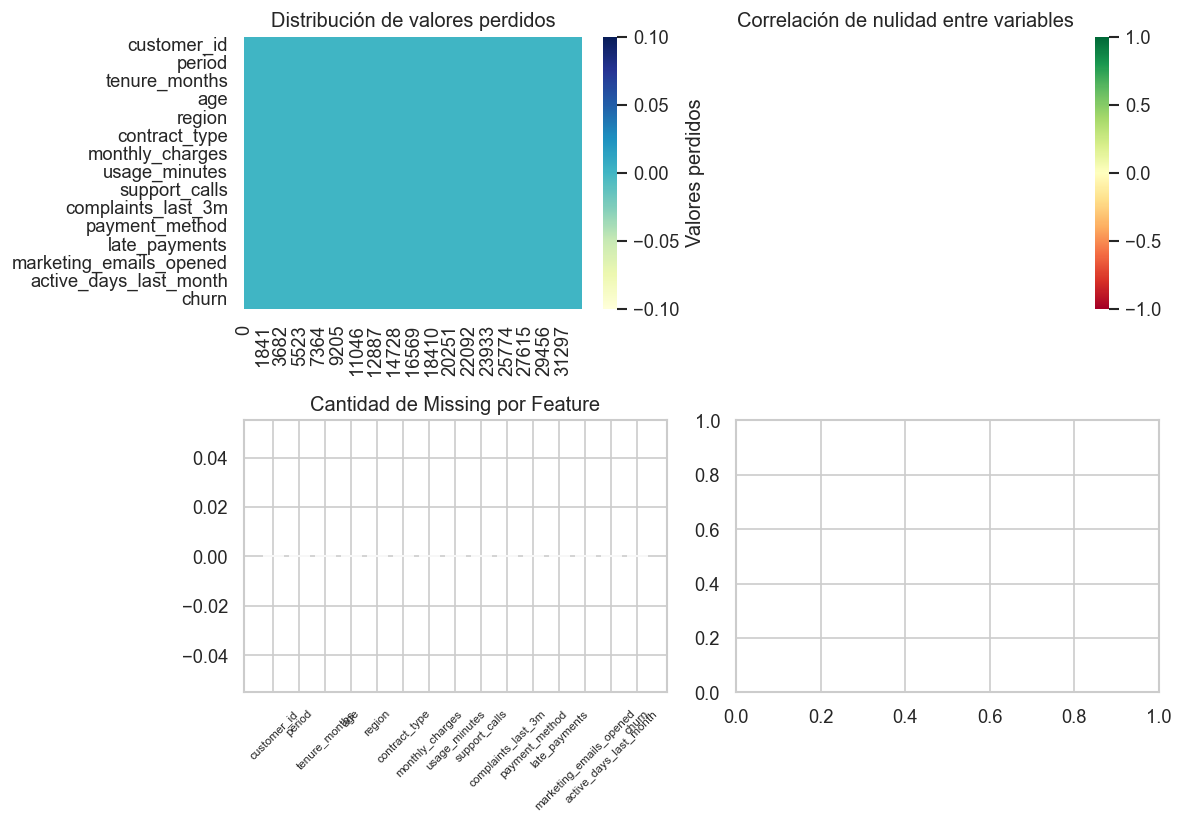

In [35]:
# Missings

fig, ax = plt.subplots(2, 2, figsize = (10, 7))
axes = ax.flatten()

sns.heatmap(
    data= df.isnull().transpose(),
    cmap= 'YlGnBu',
    cbar_kws = {'label': 'Valores perdidos'},
    ax= axes[0]
)
axes[0].set_title('Distribución de valores perdidos')

missingno.heatmap(
    df= df,
    cmap= 'RdYlGn',
    figsize= (10,5),
    fontsize= 12,
    ax = axes[1]
)
axes[1].set_title('Correlación de nulidad entre variables')

axes[2].bar(
    missings_df['feature'],
    missings_df['Cantidad de Missings'],
)
axes[2].tick_params(axis = 'x', rotation = 45, labelsize = 7)
axes[2].set_title('Cantidad de Missing por Feature')
plt.tight_layout()
plt.show()

In [39]:
print('=== Reporte de Missings ===')
print(f'''El dataset NO presenta ningún missing''')
print(f'Se evaluó lo siguiente:')
print(f'- Distribución de valores perdidos        : Sin resultados')
print(f'- Correlación de nulidad entre variables  : Sin resultados') 
print(f'- Cantidad de missing por feature         : Sin resultados')

=== Reporte de Missings ===
El dataset NO presenta ningún missing
Se evaluó lo siguiente:
- Distribución de valores perdidos        : Sin resultados
- Correlación de nulidad entre variables  : Sin resultados
- Cantidad de missing por feature         : Sin resultados


### Features Numéricas

In [11]:
FEATS_NUMERICAS = [
    'tenure_months',
    'age',
    'active_days_last_month',
    'marketing_emails_opened',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'usage_minutes',
    'monthly_charges'
]
FEATS_CATEGORICAS = [
    'region',
    'payment_method',
    'contract_type'
]
TARGET = 'churn'
PERIODO = 'period'

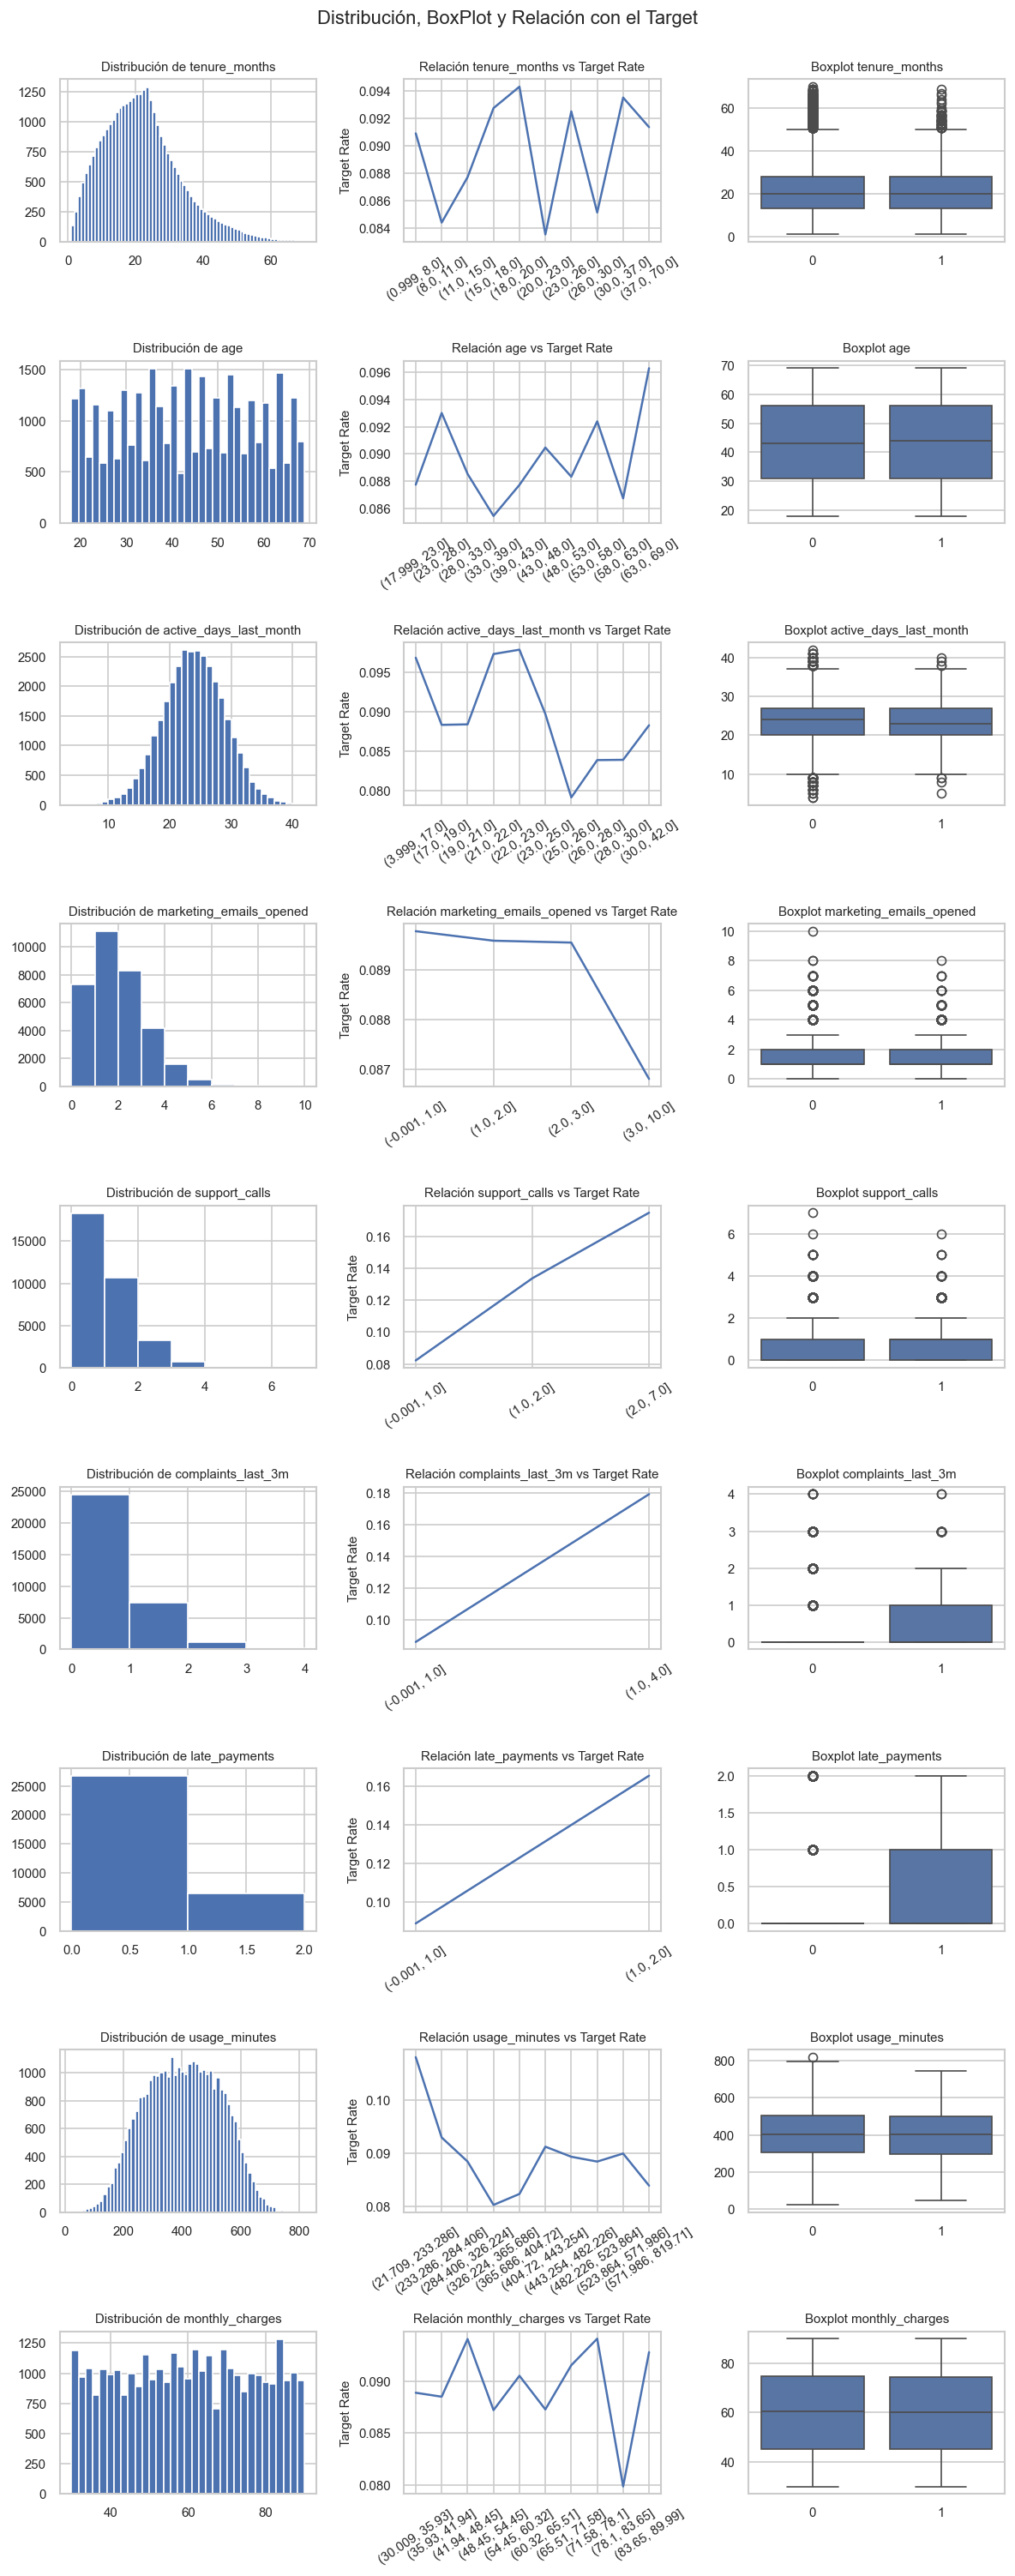

In [61]:
## Distribución y BoxPlot

fig, ax = plt.subplots(9, 3, figsize = (10, 25))
#axes = ax.flatten()

for i, var in enumerate(FEATS_NUMERICAS):
    ax[i,0].hist(
        df[var],
        bins = 'auto'
    )
    ax[i, 0].set_title(f'Distribución de {var}', fontsize = 9)
    ax[i, 0].tick_params(axis= 'x', labelsize = 9)
    ax[i, 0].tick_params(axis = 'y', labelsize = 9)

    sns.boxplot(
        data = df,
        x = TARGET,
        y = var,
        ax= ax[i,2]
        #orient = 'v'
        
    )
    ax[i,2].set_title(f'Boxplot {var}', fontsize = 9)
    ax[i,2].tick_params(axis='x', labelsize = 9)
    ax[i,2].tick_params(axis='y', labelsize = 9)
    ax[i,2].set_xlabel("")
    ax[i,2].set_ylabel("")

    df_tmp = df.copy()
    df_tmp['bin'] = pd.qcut(
        x= df[var],
        q= 10,
        duplicates= 'drop'
    )
    agg = df_tmp.groupby(
        ['bin']
    ).agg(
        event_rate = (TARGET, 'mean')
    ).reset_index(level= 0, drop= False)
    agg['bin'] = agg['bin'].astype(str)
    
    sns.lineplot(
        data= agg,
        ax= ax[i,1],
        x= 'bin',
        y= 'event_rate',
        markers= 'o',
        
    )
    ax[i,1].set_title(f'Relación {var} vs Target Rate', fontsize = 9)
    ax[i,1].tick_params(axis = 'x', labelsize = 9, labelrotation= 34)
    ax[i,1].tick_params(axis = 'y', labelsize = 9)
    ax[i,1].set_xlabel("")
    ax[i,1].set_ylabel("Target Rate", fontsize = 9)
    
    
    # agg = df.groupby(
    #     TARGET
    # ).agg(
    #     mean = (var, 'mean')
    # ).reset_index(level= 0, drop= False)
    
    # bar = ax[i,2].bar(
    #     agg['churn'],
    #     round(agg['mean'],2)
    # )
    # ax[i,2].bar_label(bar, fontsize = 9)
    # ax[i,2].tick_params(axis = 'x', labelsize = 9)
    # ax[i,2].tick_params(axis = 'y', labelsize = 9)
    # ax[i,2].set_title(f'{var} vs Promedio Churn', fontsize = 9)

    
plt.suptitle('Distribución, BoxPlot y Relación con el Target', y= 1.0001)
plt.tight_layout()

In [62]:
print('=== Reporte de Features Numéricas ===')
print('''Se puede observar lo siguiente:
- Existe relación monotónica creciente en las siguientes features: 
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Las siguientes features tienen una cola hacia la derecha:
      - "marketing_emails_opened"
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Pero al ser estas últimas variables discretas (conteos) y de baja cardinalidad,
no será necesaria ninguna transformación.
''')


=== Reporte de Features Numéricas ===
Se puede observar lo siguiente:
- Existe relación monotónica creciente en las siguientes features: 
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Las siguientes features tienen una cola hacia la derecha:
      - "marketing_emails_opened"
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Pero al ser estas últimas variables discretas (conteos) y de baja cardinalidad,
no será necesaria ninguna transformación.



### Features Categóricas

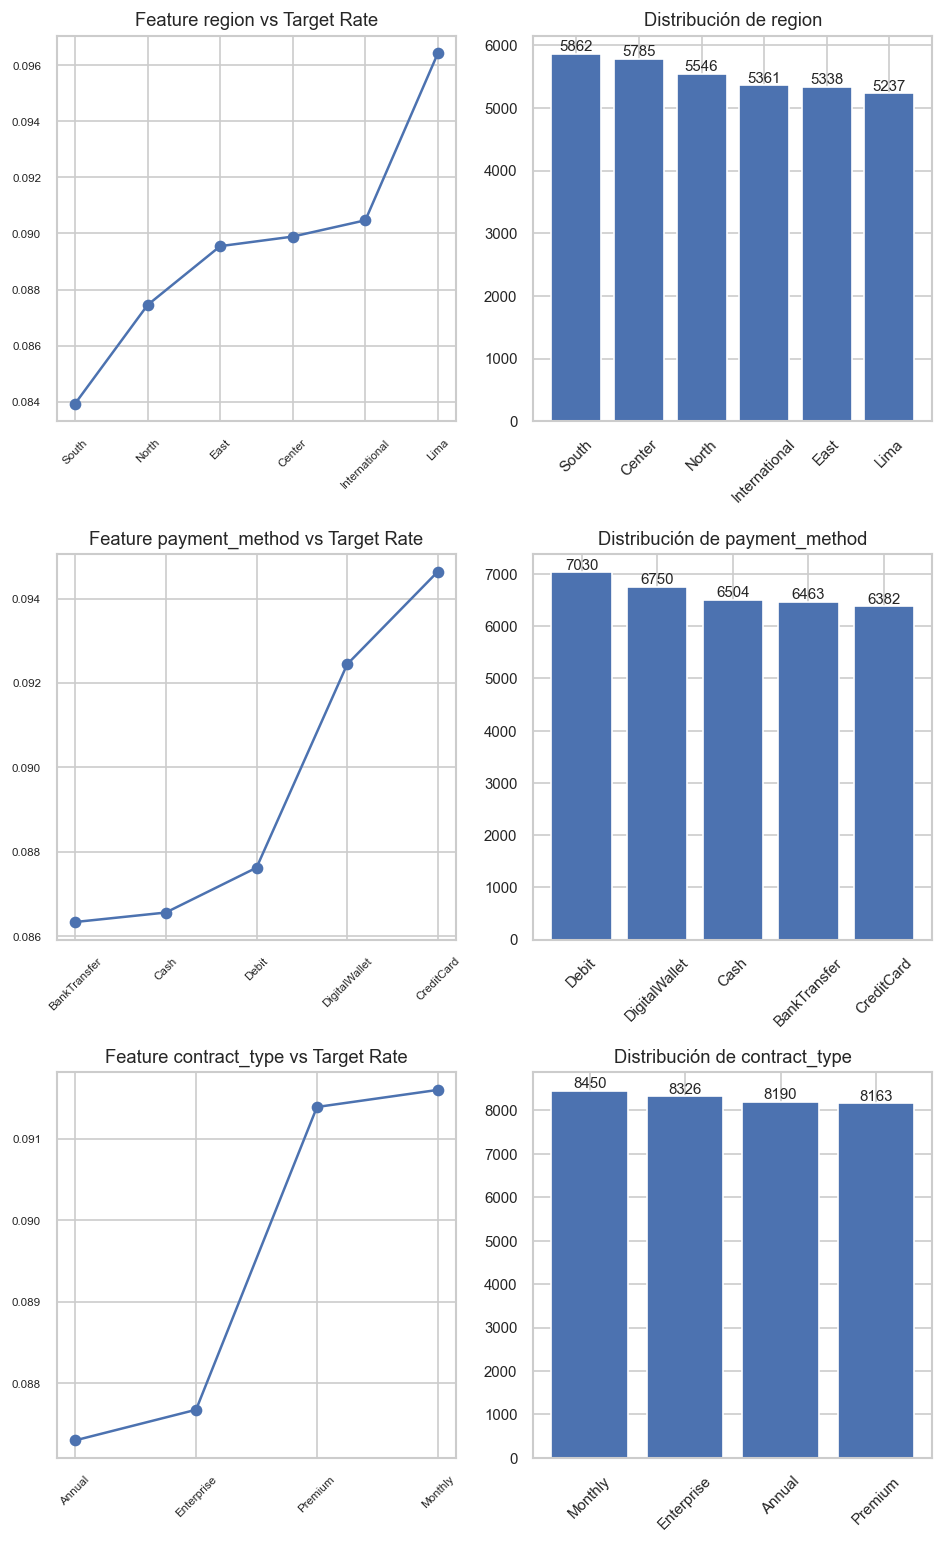

In [96]:
fig, ax = plt.subplots(3, 2, figsize = (8, 13))
for i, var in enumerate(FEATS_CATEGORICAS):
    agg = df.groupby(
        [var]
    ).agg(
        mean_target = (TARGET, 'mean'),
        count_var = (var, 'count')
    ).reset_index(level=0, drop= False).sort_values(by= 'mean_target', ascending= True)
    
    ax[i,0].plot(
        agg[var],
        agg['mean_target'],
        marker = 'o'
    )
    ax[i,0].tick_params(axis = 'x', labelsize = 7, rotation = 45)
    ax[i,0].tick_params(axis = 'y', labelsize = 7)
    ax[i,0].set_title(f'Feature {var} vs Target Rate', fontsize = 11)

    agg = agg.sort_values(by= 'count_var', ascending = False)
    bar = ax[i,1].bar(
        agg[var],
        agg['count_var'],
    )
    ax[i,1].bar_label(bar, fontsize = 9)
    ax[i,1].set_title(f'Distribución de {var}', fontsize = 11)
    ax[i,1].tick_params(axis = 'x', labelsize = 9, rotation = 45)
    ax[i,1].tick_params(axis = 'y', labelsize = 9)
plt.tight_layout()
plt.show()

In [100]:
print('=== Reporte de Features Categóricas ===')
print(f'''Se identificó que aunque existe ligeros aumentos del churn rate promedio 
entre las categorías del mismo feature, no es un aumento considerable y tampoco
existe una relación ordinal clara para separarlo ordinalmente.

Además, la distribución de cada feature categórica muestra que no existen etiquetas 
o niveles raros a considerar. 
      
Posible features con OHE:
      - region
      - payment_method
      - contract_type
''')

=== Reporte de Features Categóricas ===
Se identificó que aunque existe ligeros aumentos del churn rate promedio 
entre las categorías del mismo feature, no es un aumento considerable y tampoco
existe una relación ordinal clara para separarlo ordinalmente.

Además, la distribución de cada feature categórica muestra que no existen etiquetas 
o niveles raros a considerar. 

Posible features con OHE:
      - region
      - payment_method
      - contract_type



### Registros por período y Churn por período

In [202]:
## Registros por período
agg_period = df.groupby(
    ['period']
).agg(
    n_registros = (TARGET, 'count'),
    n_event = (TARGET, 'sum'),
    target_mean = (TARGET, 'mean')
).reset_index(level= 0, drop = False)
agg_period['n_no_event'] = agg_period['n_registros'] - agg_period['n_event']

agg_period_2023_2024 = agg_period.loc[agg_period['period'] < '2025-01-01']
agg_period_2025 = agg_period.loc[(agg_period['period'] > '2024-12-01') & (agg_period['period'] < '2026-01-01')]
agg_period_2026 = agg_period.loc[(agg_period['period'] > '2025-12-01') & (agg_period['period'] < '2027-01-01')]

share_registros_2023_2024 = agg_period_2023_2024['n_registros'].sum() / agg_period['n_registros'].sum()
share_registros_2025 = agg_period_2025['n_registros'].sum() / agg_period['n_registros'].sum()
share_registros_2026 = agg_period_2026['n_registros'].sum() / agg_period['n_registros'].sum()

media_2023_2024 = df.loc[df['period'] < '2025-01-01'][TARGET].mean()
media_2025 = df.loc[(df['period'] > '2024-12-01') & (df['period'] < '2026-01-01')][TARGET].mean()
media_2026 = df.loc[(df['period'] > '2025-12-01') & (df['period'] < '2027-01-01')][TARGET].mean()

## Métricas auxiliares para tercer gráfico
event_rate_2023_2024 = agg_period_2023_2024['n_event'].sum() / agg_period_2023_2024['n_registros'].sum()
no_event_rate_2023_2024 = agg_period_2023_2024['n_no_event'].sum() / agg_period_2023_2024['n_registros'].sum()

event_rate_2025 = agg_period_2025['n_event'].sum() / agg_period_2025['n_registros'].sum()
no_event_rate_2025 = agg_period_2025['n_no_event'].sum() / agg_period_2025['n_registros'].sum()

event_rate_2026 = agg_period_2026['n_event'].sum() / agg_period_2026['n_registros'].sum()
no_event_rate_2026 = agg_period_2026['n_no_event'].sum() / agg_period_2026['n_registros'].sum()


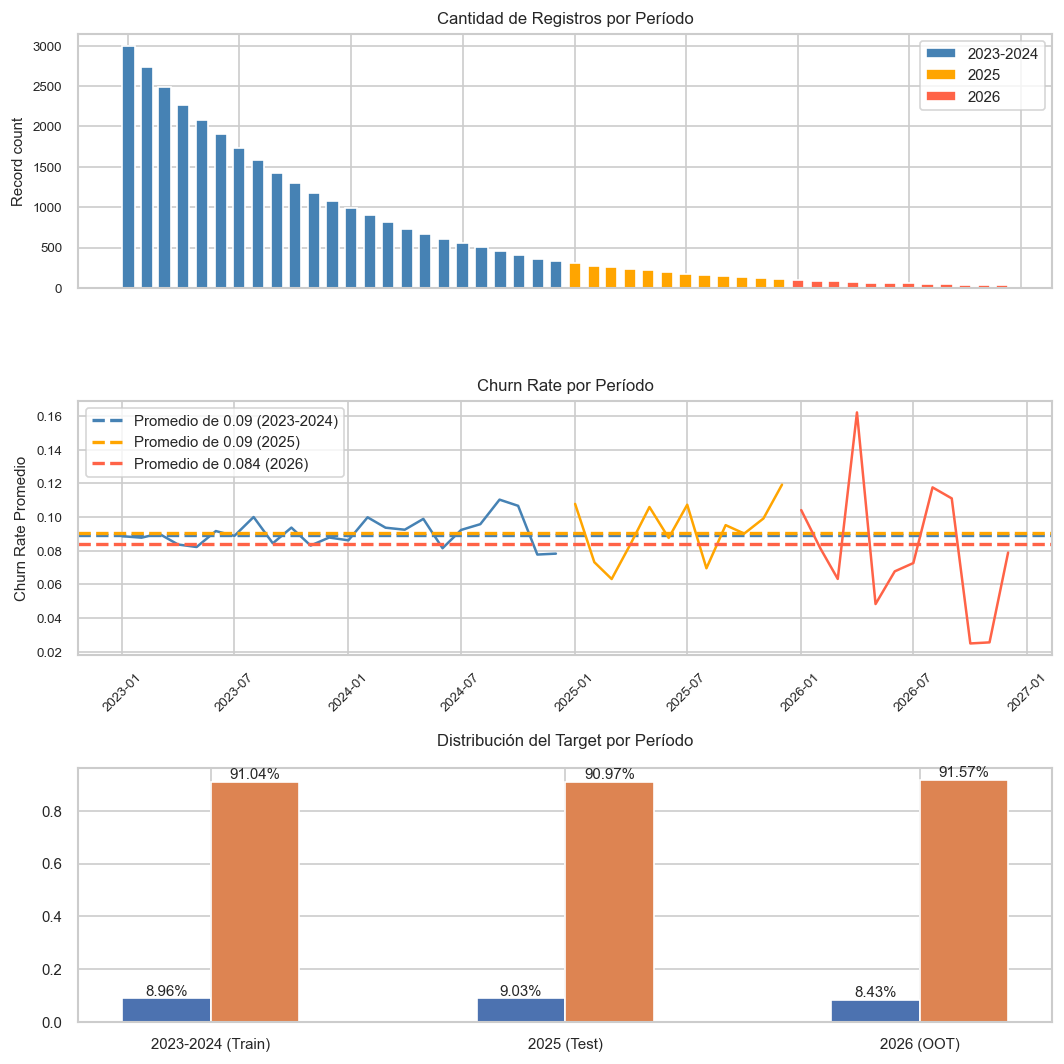

In [201]:
fig, ax = plt.subplots(3, 1, figsize = (9, 9))
ax[0].bar(
    agg_period_2023_2024['period'],
    agg_period_2023_2024['n_registros'],
    color = 'steelblue',
    width= 20,
    label = '2023-2024'
)

ax[0].bar(
    agg_period_2025['period'],
    agg_period_2025['n_registros'],
    width = 20,
    color = 'orange',
    label = '2025'
)

ax[0].bar(
    agg_period_2026['period'],
    agg_period_2026['n_registros'],
    width = 20,
    color = 'tomato',
    label = '2026'
)
ax[0].set_ylabel('Record count', fontsize = 9)
ax[0].tick_params(axis = 'y', labelsize = 8)
ax[0].tick_params(axis = 'x', labelbottom = False)
ax[0].set_title(f'Cantidad de Registros por Período', fontsize = 10)
ax[0].legend(fontsize = 9)

## Gráfico 2
ax[1].plot(
    agg_period_2023_2024['period'],
    agg_period_2023_2024['target_mean'],
    color = 'steelblue',
    #marker = 'o'
)
ax[1].axhline(
    y = media_2023_2024,
    color = 'steelblue',
    linestyle = '--',
    linewidth= 2,
    label = f'Promedio de {round(media_2023_2024,3)} (2023-2024)'
)

ax[1].plot(
    agg_period_2025['period'],
    agg_period_2025['target_mean'],
    color = 'orange',
    #marker = 'o'
)

ax[1].axhline(
    y = media_2025,
    color = 'orange',
    linestyle = '--',
    linewidth = 2,
    label = f'Promedio de {round(media_2025, 3)} (2025)'
)

ax[1].plot(
    agg_period_2026['period'],
    agg_period_2026['target_mean'],
    color = 'tomato'
)

ax[1].axhline(
    y = media_2026,
    color = 'tomato',
    linestyle = '--',
    linewidth = 2,
    label = f'Promedio de {round(media_2026, 3)} (2026)'
)

ax[1].set_title('Churn Rate por Período', fontsize = 10)
ax[1].set_ylabel('Churn Rate Promedio', fontsize = 9)
ax[1].tick_params(axis = 'x', labelsize = 8, rotation = 45)
ax[1].tick_params(axis = 'y', labelsize = 8)
ax[1].legend(fontsize = 9)

## Gráfico 3
 
categorias = ['2023-2024 (Train)', '2025 (Test)', '2026 (OOT)']
x = np.arange(len(categorias))
width = 0.25

serie_event_rate = [event_rate_2023_2024, event_rate_2025, event_rate_2026]
serie_no_event_rate = [no_event_rate_2023_2024, no_event_rate_2025, no_event_rate_2026]

bar_1 = ax[2].bar(
    x - width/2,
    serie_event_rate,
    width,
    label = 'Event Rate'
)

bar_2 = ax[2].bar(
    x + width/2,
    serie_no_event_rate,
    width,
    label = 'No Event Rate'
)
ax[2].bar_label(bar_1, labels = [f'{d:.2%}' for d in serie_event_rate], fontsize = 9)
ax[2].bar_label(bar_2, labels = [f'{d:.2%}' for d in serie_no_event_rate], fontsize = 9)

ax[2].set_xticks(x)
ax[2].set_xticklabels(categorias)
ax[2].set_title('Distribución del Target por Período', fontsize = 10, y = 1.05)
ax[2].tick_params(axis = 'x', labelsize = 9)
ax[2].tick_params(axis = 'y', labelsize = 9)

plt.tight_layout()
plt.show()

In [209]:
print('=== Reporte de Registros por Período y Churn por Período ===')
print(f'''
Se observa que la cantidad de registros por período es mayor en los primeros meses 
y tiene una tendencia decreciente hasta el final del mismo.
    - Registros en Train   : {share_registros_2023_2024:.2%}
    - Registros en Test    : {share_registros_2025:.2%}
    - Registros en OOT     : {share_registros_2026:.2%}

Respecto al Churn Rate por período, se observa que tanto el período de Train y Test
son muy similares en comportamiento con igual promedio global de ambos.
Por otro lado, el período propuesto como OOT (2026) sí varía ligeramente el promedio
global y tiene meses con un pico alto de Churn Rate y otros dos bastante bajos.
Se considerará esto al momento de analizar el monitoring y drift.

Por último, respecto a la distribución del Churn por período, se observa un cambio
en la prevalencia del OOT (-0.6pp vs Test | -0.53pp vs Train), al ser un cambio ligero,
se monitoreará principalmente en Calibration Drift.
''')

=== Reporte de Registros por Período y Churn por Período ===

Se observa que la cantidad de registros por período es mayor en los primeros meses 
y tiene una tendencia decreciente hasta el final del mismo.
    - Registros en Train   : 90.80%
    - Registros en Test    : 7.02%
    - Registros en OOT     : 2.19%

Respecto al Churn Rate por período, se observa que tanto el período de Train y Test
son muy similares en comportamiento con igual promedio global de ambos.
Por otro lado, el período propuesto como OOT (2026) sí varía ligeramente el promedio
global y tiene meses con un pico alto de Churn Rate y otros dos bastante bajos.
Se considerará esto al momento de analizar el monitoring y drift.

Por último, respecto a la distribución del Churn por período, se observa un cambio
en la prevalencia del OOT (-0.6pp vs Test | -0.53pp vs Train), al ser un cambio ligero,
se monitoreará principalmente en Calibration Drift.



### Split Resumen

In [206]:
# Split | Período | Rows | Churn Rate

split_resumen = pd.DataFrame({
    'Split': ['Train', 'Test', 'OOT'],
    'Período': ['2023-2024', '2025', '2026'],
    'Rows': [agg_period_2023_2024['n_registros'].sum(), agg_period_2025['n_registros'].sum(), agg_period_2026['n_registros'].sum()],
    'Churn Rate': [event_rate_2023_2024, event_rate_2025, event_rate_2026]
})
split_resumen


,Split,Período,Rows,Churn Rate
0,Train,2023-2024,30080,0.089561
1,Test,2025,2325,0.090323
2,OOT,2026,724,0.084254


### Análisis de Correlación Pearson, Spearman, VIF (+IV)